In [1]:
# %%
import sys
sys.path.append("/home/jiahuang/test-code-hazel/")
import gen_fxns
import h5py
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import scipy as sp
import sklearn
from datetime import date
import pandas as pd 
from datetime import timedelta
from scipy.stats import zscore
import seaborn as sns 
import pickle 
import os 
from datetime import datetime
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm

In [ ]:
# %%
behav_score_allpt = {}
all_data_clean_roi_z_allpt = {}
all_data_clean_freq_roi_z_allpt = {}
all_data_clean_freq_z_allpt = {}
behavior_raw_allpt = {}
all_channel_labels_allpt = {}
ch_allpt = {}
ptIDs = [
        'RCS02'
         ,'RCS03','RCS04','RCS05','RCS06','RCS07','RCS08'
         ,'RCS09'
        ]

# %%
for ptID in ptIDs:
    path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
    # fig_save = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/meanpsd_mad_072026"
    pt_path = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"
    # pt_path = f"/home/rvatsyayan/AnushaData"
    electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df_updated072026.csv")
    data_root = Path(path_string)
    # file_keyword = '_meanpsd_clean'
    file_keyword = '_meanpsd_clean'
    dataset_name = "mean_psd" # files with mean power spectral density 

    # os.makedirs(fig_save, exist_ok=True)

    # hamd_path_string = Path(f"/userdata/rvatsyayan/AnushaData/HDF5 HAMD Data/{ptID}") 
    # hamd_data_root = Path(hamd_path_string)

    # Function to extract numeric part from filename
    def extract_number(filename):
        return int(''.join(filter(str.isdigit, filename)))

    def load_h5_files(path_string, pt_path, 
                    #   hamd_path, 
                    file_keyword, dataset_name):
        import re
        h5_arrays = []
        hamd_arrays = {}
        fileids = [] 
        # Get list of files in directory and sort them based on numeric part
        files = sorted(os.listdir(path_string), key=extract_number)
        # hamd_files = sorted(os.listdir(hamd_path), key=extract_number)
        
        for filename in files:
            if filename.endswith('_meanpsd_clean.h5'):
            # and file_keyword in filename:
                # Construct the full file path
                filepath = os.path.join(path_string, filename)
                # Load the .h5 file
                with h5py.File(filepath, 'r') as hf:
                    # Assuming you want to load the first dataset from each file
                    # Load the dataset as float32
                    dataset = np.array(hf[dataset_name], dtype=np.float32)
                    
                    # raw_psd = np.array(hf["decomp_signal"], dtype=np.float32)
                    # psd_clean, stats = mad_artifact_removal(raw_psd, threshold_factor=3.5)
                    # mean_psd = np.nanmean(psd_clean, axis=1)

                    # Append the dataset to the list
                    h5_arrays.append(dataset)
                    # h5_arrays.append(mean_psd)


        files = sorted(os.listdir(pt_path), key=extract_number)
        for filename in files:
            if filename.endswith('.h5'):
                with h5py.File(os.path.join(pt_path, filename), 'r') as hf:
                    # get record_id 
                    fileid_pre = (pd.DataFrame(hf['pain_info']).iloc[1,0]).decode('utf-8')
                    fileid = datetime.strptime(fileid_pre, '%d-%b-%Y %H:%M:%S')
                    fileids.append(fileid)
        fileids = pd.to_datetime(fileids)

        return h5_arrays, fileids, hamd_arrays

    h5_arrays,fileids, hamd_arrays = load_h5_files(path_string, pt_path, file_keyword, dataset_name)



    # %%

    # concatenate data and zscore 
    all_data  = []
    all_data = np.stack(h5_arrays, axis=2)
    print("freqs x channels x trials:", all_data.shape) 
    del h5_arrays
    from scipy.stats import zscore
    psd_z = zscore(all_data,axis = 2) #freqs x channels x trials: e.g. (40, 124, 241)



    # %%
    file = f"/home/rvatsyayan/AnushaData/Pain_Scores_{ptID}.xlsx"
    raw_surveys = pd.read_excel(file)
    n_trials = raw_surveys.shape[0]
    missing_bm_data = np.setdiff1d(raw_surveys.Timestamp, fileids)
    missing_surveys = np.setdiff1d(fileids, raw_surveys.Timestamp)
    missing_channels = [i for i in range(all_data.shape[1]) if np.any(all_data[:,i,:])!=0]
    removed = [i for i in range(all_data.shape[1]) if np.any(all_data[:,i,:])==0]

    electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df_updated072026.csv")

    electrode_df["edf_ch_idx"] = (
        electrode_df["EDF Channel Number"]
        # .astype(str)
        # .str.replace(r"[^\d]", "", regex=True)
        # .astype(int)
        - 1
    )
    electrode_df_idx = [i for i in range(electrode_df.shape[0]) if str(electrode_df['New ROI Label Hazel'][i])!='nan']
    sorted_electrode_df = electrode_df.iloc[electrode_df_idx].sort_values('New ROI Label Hazel')
    save_idx_sorted = sorted_electrode_df['edf_ch_idx'].to_numpy()
    save_idx_sorted_clean = np.array(
        [i for i in save_idx_sorted if i in missing_channels]
    )
    electrode_df_clean = electrode_df[
        electrode_df["edf_ch_idx"].isin(save_idx_sorted_clean)
    ]
    electrode_df_clean = (
        electrode_df_clean
        .set_index("edf_ch_idx")
        .loc[save_idx_sorted_clean]
        .reset_index()
    )
    electrode_indices_by_ROI = (
        electrode_df_clean
        .groupby("New ROI Label Hazel")["edf_ch_idx"]
        .apply(list)
        .to_dict()
    )

    print(electrode_indices_by_ROI)

    # remove missing survey record ids from neural data. 
    idx_missing_surveys = ~np.isin(fileids, missing_surveys)

    new_alldata = psd_z[:,:,idx_missing_surveys]

    # idx_missing_neuraldata = ~np.isin(raw_surveys.record_id, missing_bm_data)
    idx_missing_neuraldata = ~np.isin(raw_surveys.Timestamp, missing_bm_data)
    new_surveys = raw_surveys.iloc[idx_missing_neuraldata]

    assert(new_surveys.shape[0] == new_alldata.shape[2])

    # %%
    ## reshape and zscore surveys. 
    # psd_z_vec = new_alldata.reshape(new_alldata.shape[2], -1)
    n_freq = new_alldata.shape[0]
    n_ch = len(save_idx_sorted_clean)
    n_feats = n_freq * n_ch  # num of neural features
    n_trials = new_alldata.shape[2]
    # psd_z_vec = np.reshape(new_alldata, (n_feats, n_trials))

    def man_z_score(array):
        array_mean = np.nanmean(array)
        array_std = np.nanstd(array)
        zscore_array = (array - array_mean)/array_std
        return zscore_array
    # new_surveys.fillna(0, inplace=True)
    vasp = new_surveys['intensity_vas_s0'].to_numpy()
    vasd = new_surveys['mood_vas_s0'].to_numpy() # depression/mood survey scores 
    nrs = new_surveys['nrs_s0'].to_numpy()
    unpleasantness = new_surveys['unpleasantness_vas_s0'].to_numpy()
    mpq_somatic = new_surveys.iloc[:,7:18]
    mpq_affective = new_surveys[['tiring_exhausting_s0', 'sickening_s0', 'fearful_s0','punishing_cruel_s0']]
    sum_affective = np.sum(mpq_affective,axis=1).to_numpy()
    sum_somatic = np.sum(mpq_somatic,axis=1).to_numpy()

    vasp_vec = vasp.reshape(-1)
    vasd_vec = vasd.reshape(-1)
    nrs_vec = nrs.reshape(-1)
    sum_affective_vec = sum_affective.reshape(-1)
    sum_somatic_vec = sum_somatic.reshape(-1)
    unpleasantness_vec = unpleasantness.reshape(-1)

    if ptID == 'RCS08':
        mask_valid = (
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_affective_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    elif ptID == 'RCS09':
        mask_valid = (
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    else:
        mask_valid = (
            ~np.isnan(vasd_vec) &
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_affective_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )

    vasp_clean = vasp_vec[mask_valid]
    vasd_clean = vasd_vec[mask_valid]
    nrs_clean = nrs_vec[mask_valid]
    sum_affective_clean = sum_affective_vec[mask_valid]
    sum_somatic_clean = sum_somatic_vec[mask_valid]
    unpleasantness_clean = unpleasantness_vec[mask_valid]

    vasd_z_clean = man_z_score(vasd_clean)
    nrs_z_clean = man_z_score(nrs_clean)
    affective_z_clean = man_z_score(sum_affective_clean)
    somatic_z_clean = man_z_score(sum_somatic_clean)
    unpleasant_z_clean = man_z_score(unpleasantness_clean)
    vasp_z_clean = man_z_score(vasp_clean)

    new_surveys = new_surveys.loc[mask_valid,:]


    # # PCA behavioral composite score
    from sklearn.decomposition import PCA
    # rcs08: X_score = np.stack([nrs_z_clean, affective_z_clean], axis=1)
    # rcs09: X_score = np.stack([nrs_z_clean], axis=1)
    if ptID == 'RCS08':
        X_score = np.stack([unpleasant_z_clean, affective_z_clean,vasp_z_clean, nrs_z_clean, somatic_z_clean], axis=1)
        var_labels = ['unpleasantness','mpq-affective','vasp','nrs','mpq-somatic']
    elif ptID == 'RCS09':
        X_score = np.stack([unpleasant_z_clean,vasp_z_clean, nrs_z_clean, somatic_z_clean], axis=1)
        var_labels = ['unpleasantness','vasp','nrs','mpq-somatic']
    else:
        X_score = np.stack([-vasd_z_clean, unpleasant_z_clean, affective_z_clean,vasp_z_clean, nrs_z_clean, somatic_z_clean], axis=1)
        var_labels = ['vasd-r','unpleasantness','mpq-affective','vasp','nrs','mpq-somatic']

    model = PCA(n_components=3)
    pca_stack_score = model.fit_transform(X_score)

    from sklearn.decomposition import PCA
    import numpy as np

    if ptID == 'RCS08':

        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_labels = [
            'vasp',
            'nrs',
            'mpq-somatic'
        ]

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            unpleasant_z_clean,
            affective_z_clean
        ], axis=1)

        affective_labels = [
            'unpleasantness',
            'mpq-affective'
        ]

        affective_pca = PCA(n_components=2)
        affective_latent = affective_pca.fit_transform(X_affective)

    elif ptID == 'RCS09':
        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_labels = [
            'vasp',
            'nrs',
            'mpq-somatic'
        ]

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            unpleasant_z_clean
        ], axis=1)

        affective_labels = [
            'unpleasantness'
        ]

        affective_latent = unpleasant_z_clean.copy()


    else:
        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_labels = [
            'vasp',
            'nrs',
            'mpq-somatic'
        ]

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            -vasd_z_clean,
            unpleasant_z_clean,
            affective_z_clean
        ], axis=1)

        affective_labels = [
            'vasd-r',
            'unpleasantness',
            'mpq-affective'
        ]

        affective_pca = PCA(n_components=3)
        affective_latent = affective_pca.fit_transform(X_affective)

    # ============================================
    # STORE PCA RESULTS
    # ============================================

    pca_results = {}

    pca_results['all'] = {
        'model':model,
        'scores':pca_stack_score,
        'loadings': model.components_,
        'variance_explained': model.explained_variance_ratio_,
        'labels': var_labels
    }
    pca_results['sensory'] = {
        'model': sensory_pca,
        'scores': sensory_latent,
        'loadings': sensory_pca.components_,
        'variance_explained': sensory_pca.explained_variance_ratio_,
        'labels': sensory_labels
    }

    if ptID != 'RCS09':
        pca_results['affective'] = {
            'model': affective_pca,
            'scores': affective_latent,
            'loadings': affective_pca.components_,
            'variance_explained': affective_pca.explained_variance_ratio_,
            'labels': affective_labels
        }
    else:
        pca_results['affective'] = {
            'scores': affective_latent,
            'labels': affective_labels
        }


    # %%
    new_labels = sorted(['IC', 'Caudate', 'ACC', 'MCC','OFC', 'AINS', 'PINS','dmPFC','dlPFC','THAL'])
    new_labels_bi = sorted(['L '+nl for nl in new_labels] + ['R '+ nl for nl in new_labels])

    # Dimension reduction of all_data
    clean_alldata = psd_z[:,:,idx_missing_surveys]
    clean_alldata= clean_alldata[:,:,mask_valid]
    # clean_alldata = clean_alldata[:,missing_channels,:]
    print(clean_alldata.shape)
    n_ch_all = clean_alldata.shape[1]
    n_trials = clean_alldata.shape[2]

    band_data = np.zeros((6, n_ch_all, n_trials))
    bandref = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,12), 'beta':(12,30), 'low gamma':(30,70), 'high gamma':(70,150)}
    bands = list(bandref.keys())

    import re
    ch_labels = []
    freqs = []
    if ptID == 'RCS08':
        with h5py.File(f"{path_string}/5_meanpsd.h5", 'r') as hf:
            freqs = hf.attrs['freqs']
    else:
        with h5py.File(f"{path_string}/1_meanpsd.h5", 'r') as hf:
            freqs = hf.attrs['freqs']
    canonical_freq = [bandref[bands[i]][0] for i in range(len(bands))]


    for b in range(len(bands)):
        band = bands[b]
        (fmin, fmax) = bandref[band]
        idxf = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        band_data[b, :, :] = np.nanmean(clean_alldata[idxf, :, :], axis=0)

    large_ROI = list(electrode_indices_by_ROI.keys())
    ch_data = np.zeros((len(bands), len(large_ROI), n_trials))

    for i in range(len(large_ROI)):
        ch = large_ROI[i]
        idxc = electrode_indices_by_ROI[ch]
        ch_data[:,i,:] = np.nanmean(band_data[:, idxc, :], axis = 1)

    ch_data_new = np.zeros((len(freqs), len(large_ROI), n_trials))

    for i in range(len(large_ROI)):
        ch = large_ROI[i]
        idxc = electrode_indices_by_ROI[ch]
        ch_data_new[:,i,:] = np.nanmean(clean_alldata[:, idxc, :], axis = 1)


    all_channel_labels = (
        electrode_df_clean["New ROI Label Hazel"].astype(str) + "_" + electrode_df_clean.groupby("New ROI Label Hazel").cumcount().add(1).astype(str)
    ).tolist()    

    print(all_channel_labels)
    all_channel_labels_allpt[ptID] = all_channel_labels

    band_data_temp = band_data[:,save_idx_sorted_clean,:]
    
    band_data_clean_ch = band_data[:, save_idx_sorted_clean, :]  # n_bands x n_channel_clean x n_trials
    n_ch_clean = band_data_clean_ch.shape[1]
    all_data_clean_band_channel_z = zscore(band_data_clean_ch, axis=2).reshape(len(bands)*n_ch_clean, n_trials).T
    all_data_clean_freq_z_allpt[ptID] = all_data_clean_band_channel_z

    all_data_clean_roi_z_allpt[ptID] = zscore(ch_data,axis=2).reshape(len(bands)*len(large_ROI), n_trials).T
    ch_allpt[ptID] = large_ROI
    behav_score_allpt[ptID] = pca_results
    behavior_raw_allpt[ptID] = {'affective': affective_z_clean,
                                'somatic': somatic_z_clean,
                                'nrs': nrs_z_clean,
                                'vasd-r': -vasd_z_clean}

In [27]:
sys.path.append("/home/jiahuang/test-code-hazel/gen_fxns/")
savepath = f"/userdata/jiahuang/pain-data/figures/Stage1-test/072026-newpreproc/meanpsd_mad_final"
import os
os.makedirs(savepath, exist_ok=True)

def basic_heatmap(ax, array, ch_labels, freqs, cbar_title, title, save=False):
    fig_params = [8, 12]
    caxis_lim = [-0.1, 0.2]
    
    sns.heatmap((array.T), cmap="RdBu_r", 
                vmax = np.nanmax(np.abs(array)), vmin = -np.nanmax(np.abs(array)), center = 0,cbar=True,
                yticklabels=new_labels_bi, xticklabels=freqs, 
                cbar_kws={'label': cbar_title}, ax=ax)
    missing_cols = [j for j, roi in enumerate(new_labels_bi) if roi not in list(ch_labels)]
    print(missing_cols)
    for col in missing_cols:
        ax.add_patch(plt.Rectangle((0, col), array.shape[0], 1,
            fill=True, facecolor='lightgray', alpha=0.6,
            hatch='////', edgecolor='gray', linewidth=0,
            zorder=3
        ))
    ax.set_xlabel("Frequency (Hz)", fontsize=15)
    ax.set_ylabel("Channel", fontsize=15)
    ax.set_title(title, fontsize=18)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=13,rotation=0)
    if save: plt.savefig(f"{savepath}/{title}.png")

def basic_heatmap_onlyone(array, ch_labels, freqs, cbar_title, title, save=False, savepath=""):
    plt.figure(figsize=(8, 12))

    vmax = np.nanmax(np.abs(array))

    ax = sns.heatmap(array.T, cmap="RdBu_r", vmax=vmax, vmin=-vmax, center=0, cbar=True,
        yticklabels=new_labels_bi,
        xticklabels=np.round(freqs),
        cbar_kws={'label': cbar_title}
    )

    missing_cols = [j for j, roi in enumerate(new_labels_bi) if roi not in list(ch_labels)]

    for col in missing_cols:
        ax.add_patch(plt.Rectangle((0, col), array.shape[0],1,
            facecolor='lightgray',alpha=0.6,hatch='////',edgecolor='gray',
            linewidth=0,zorder=3
        ))

    plt.xlabel("Frequency (Hz)",fontsize=13)
    plt.ylabel("Channel",fontsize=13)
    plt.title(title,fontsize=15)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)

    plt.tight_layout()

    if save:
        plt.savefig(f"{savepath}/{title}.png", dpi=300, bbox_inches='tight')

    plt.close()

def plot_heatmap_subplots(data_list, ch_labels, freqs, cbar_titles, titles, savetitle, nrows, ncols):
    """
    Generate subplots using the custom heatmap function.

    Parameters:
    data_list (list of ndarray): List of 2D arrays to be plotted as heatmaps.
    cbar_titles (list of str): List of colorbar titles for each heatmap.
    titles (list of str): List of titles for each heatmap.
    nrows (int): Number of rows in the subplot grid.
    ncols (int): Number of columns in the subplot grid.
    """
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8 * ncols, 10 * nrows))
    axes = axes.flatten() 

    for i, (array, ch_label, cbar_title, title) in enumerate(zip(data_list, ch_labels, cbar_titles, titles)):
        basic_heatmap(axes[i], array, ch_label, freqs, cbar_title, title)

    plt.tight_layout()
    save_dir = f"{savepath}/{savetitle}"

    plt.savefig(save_dir, dpi=600, edgecolor='k', facecolor="white")
    plt.show()

# %%
# Correlation with permutation test
def run_corr(x,y, n_freq, n_ch):
    from scipy.stats import spearmanr
    corr,p_value = spearmanr(x,y)
    correlations = corr[:-1,-1]
    p = p_value[:-1,-1].reshape(n_freq,n_ch)
    new_corr = correlations.reshape(n_freq,n_ch)
    return new_corr, p

def corr_permutation(X, Y, n_freq, n_ch, n_perm=1000):
    corr_null = np.zeros((n_perm, n_freq,n_ch))
    corr_real, __ = run_corr(X,Y,n_freq,n_ch) #return n_freq*n_ch

    for i in range(n_perm):
        Y_perm  = np.random.permutation(Y)
        null_stats, __ = run_corr(X,Y_perm, n_freq, n_ch)
        corr_null[i,:,:] = null_stats
        
    p = np.mean(np.abs(corr_null) >= np.abs(corr_real),axis=0).reshape(n_freq,n_ch)
    return corr_real, p

from statsmodels.stats.multitest import fdrcorrection

def fdr_mask(corr, pvals, alpha=0.05):

    p_flat = pvals.flatten()

    reject, p_fdr = fdrcorrection(
        p_flat,
        alpha=alpha
    )

    reject = reject.reshape(pvals.shape)

    corr_fdr = np.where(
        reject,
        corr,
        np.nan
    )

    return corr_fdr, reject


def fdr_mask_roiwise(corr, pvals, alpha=0.05):

    n_freq, n_roi = pvals.shape

    reject_all = np.zeros_like(pvals, dtype=bool)

    for roi in range(n_roi):

        reject_roi, _ = fdrcorrection(
            pvals[:, roi],
            alpha=alpha
        )

        reject_all[:, roi] = reject_roi

    corr_fdr = np.where(
        reject_all,
        corr,
        np.nan
    )

    return corr_fdr, reject_all

def make_no_data_ch_nan(data, large_ROI):
    full = np.full((data.shape[0], 20), np.nan)
    for j, roi in enumerate(new_labels_bi):
        if roi in large_ROI:
            idx = list(large_ROI).index(roi)
            full[:, j] = data[:, idx]
    return full

def get_behavior_score(pt_dict, behavior_type):

    if behavior_type == 'all':
        return pt_dict['all']['scores'][:,0]

    elif behavior_type == 'sensory':
        return pt_dict['sensory']['scores'][:,0]

    elif behavior_type == 'affective':

        if len(pt_dict['affective']['scores'].shape) == 1:
            return pt_dict['affective']['scores']

        return pt_dict['affective']['scores'][:,0]
    
def basic_heatmap_channel(array, ch_labels, freqs, cbar_title, title, save=False, savepath=""):
    n_ch = len(ch_labels)
    plt.figure(figsize=(8, 0.25*n_ch + 2))
    
    vmax = np.nanmax(np.abs(array))
    if vmax == 0 or np.isnan(vmax):
        vmax = 1
    
    ax = sns.heatmap(array.T, cmap="RdBu_r", vmax=vmax, vmin=-vmax, center=0, cbar=True,
        yticklabels=ch_labels,
        xticklabels=np.round(freqs, 1),
        cbar_kws={'label': cbar_title}
    )
    
    n_freq = len(freqs)
    if n_freq > 15:
        tick_step = max(1, n_freq // 15)
        ax.set_xticks(np.arange(0, n_freq, tick_step))
        ax.set_xticklabels(np.round(freqs[::tick_step], 1), rotation=45)
    
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Channel")
    plt.title(title)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    plt.tight_layout()
    
    if save:
        plt.savefig(f"{savepath}/{title}.png", dpi=300, bbox_inches='tight')
    plt.close()
def plot_freq_roi_dot_heatmap(corr_array, ch_labels, x_labels, roi_list, title, vmax=None, cmap='RdBu_r'):
    ch_roi = [re.sub(r'_\d+$', '', ch) for ch in ch_labels]
    n_freq = corr_array.shape[0]
    
    if vmax is None:
        vmax = np.nanmax(np.abs(corr_array))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    
    fig, ax = plt.subplots(figsize=(0.9*n_freq+3, 0.35*len(roi_list)+3))
    
    rois_present = set(ch_roi) 
    
    for fi in range(n_freq):
        for ri, roi in enumerate(roi_list):
            ch_idx = [i for i, r in enumerate(ch_roi) if r == roi]
            n = len(ch_idx)
            if n == 0:
                continue
            
            vals = corr_array[fi, ch_idx]
            vals = vals[~np.isnan(vals)]
            n_valid = len(vals)
            if n_valid == 0:
                continue
            
            if n_valid == 1:
                x_offsets = [0]
            else:
                x_offsets = np.linspace(-0.35, 0.35, n_valid)
            
            x_pos = fi + np.array(x_offsets)
            y_pos = np.full(n_valid, ri)
            ax.scatter(x_pos, y_pos, c=vals, cmap=cmap, norm=norm,
                        s=50, edgecolors='black', linewidths=0.3, zorder=3)
    
    # ---- Shade missing ROI ----
    for ri, roi in enumerate(roi_list):
        if roi not in rois_present:
            ax.add_patch(
                plt.Rectangle(
                    (-0.5, ri - 0.5), n_freq, 1,
                    facecolor='lightgray', alpha=0.5,
                    hatch='////', edgecolor='gray',
                    linewidth=0, zorder=1
                )
            )
    
    ax.set_xticks(range(n_freq))
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_yticks(range(len(roi_list)))
    ax.set_yticklabels(roi_list, fontsize=7)
    
    ax.set_xticks(np.arange(-0.5, n_freq, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(roi_list), 1), minor=True)
    ax.grid(which='minor', color='lightgray', linewidth=0.5)
    ax.tick_params(which='minor', length=0)
    
    ax.set_xlim(-0.5, n_freq-0.5)
    ax.set_ylim(-0.5, len(roi_list)-0.5)
    ax.invert_yaxis()
    
    sm = ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label='Correlation')
    
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [ ]:

corr_band_allpt = {
    'all': {},
    'sensory': {},
    'affective': {}
}

corr_fdr_allpt = {
    'all': {},
    'sensory': {},
    'affective': {}
}


behavior_types = ['sensory', 'affective']

            
for pt in ptIDs:
    for behavior in behavior_types:
        y = get_behavior_score(
            behav_score_allpt[pt],
            behavior
        )

        # =====================================
        # CANONICAL BAND PSD
        # =====================================

        corr_band, perm_p = corr_permutation(
            all_data_clean_roi_z_allpt[pt],
            y,
            len(bands),
            len(ch_allpt[pt])
        )

        # =====================================
        # uncorrected
        # =====================================

        corr_band_uncorrected = np.where(
            perm_p > 0.05,
            np.nan,
            corr_band
        )

        corr_band_fdr, reject_fdr = fdr_mask_roiwise(corr_band, perm_p)
        
        corr_band_allpt[behavior][pt] = {
            'uncorrected': make_no_data_ch_nan(corr_band_uncorrected,ch_allpt[pt]),
            'fdr': make_no_data_ch_nan(corr_band_fdr,ch_allpt[pt]),
            'raw': make_no_data_ch_nan(corr_band,ch_allpt[pt])
        }
        
        
        basic_heatmap_onlyone(corr_band_allpt[behavior][pt]['fdr'], ch_allpt[pt],canonical_freq,
                            'Corr', f'{pt} Canonical zPSD vs {behavior} PC1 FDR', True, savepath)



for behavior in behavior_types:

    plot_heatmap_subplots([corr_band_allpt[behavior][pt]['fdr'] for pt in ptIDs], [ch_allpt[pt] for pt in ptIDs],
                            canonical_freq, ['Corr'] * len(ptIDs), [f'{pt} {behavior}' for pt in ptIDs],
                            f'20260702 Group Canonical Freq Corr FDR - {behavior}', nrows=2, ncols=4 )

    
   

[0, 2, 5, 7, 10, 11, 12, 15, 16, 18]
[0, 2, 5, 10, 11, 12, 13, 15, 16]
[2, 5, 6, 13, 15, 16]
[0, 5, 6, 10, 15, 16]
[5, 9, 10, 13, 15]
[5, 9, 10, 12, 15]
[0, 1, 10, 14, 18]
[0, 8, 9, 10, 11, 16]


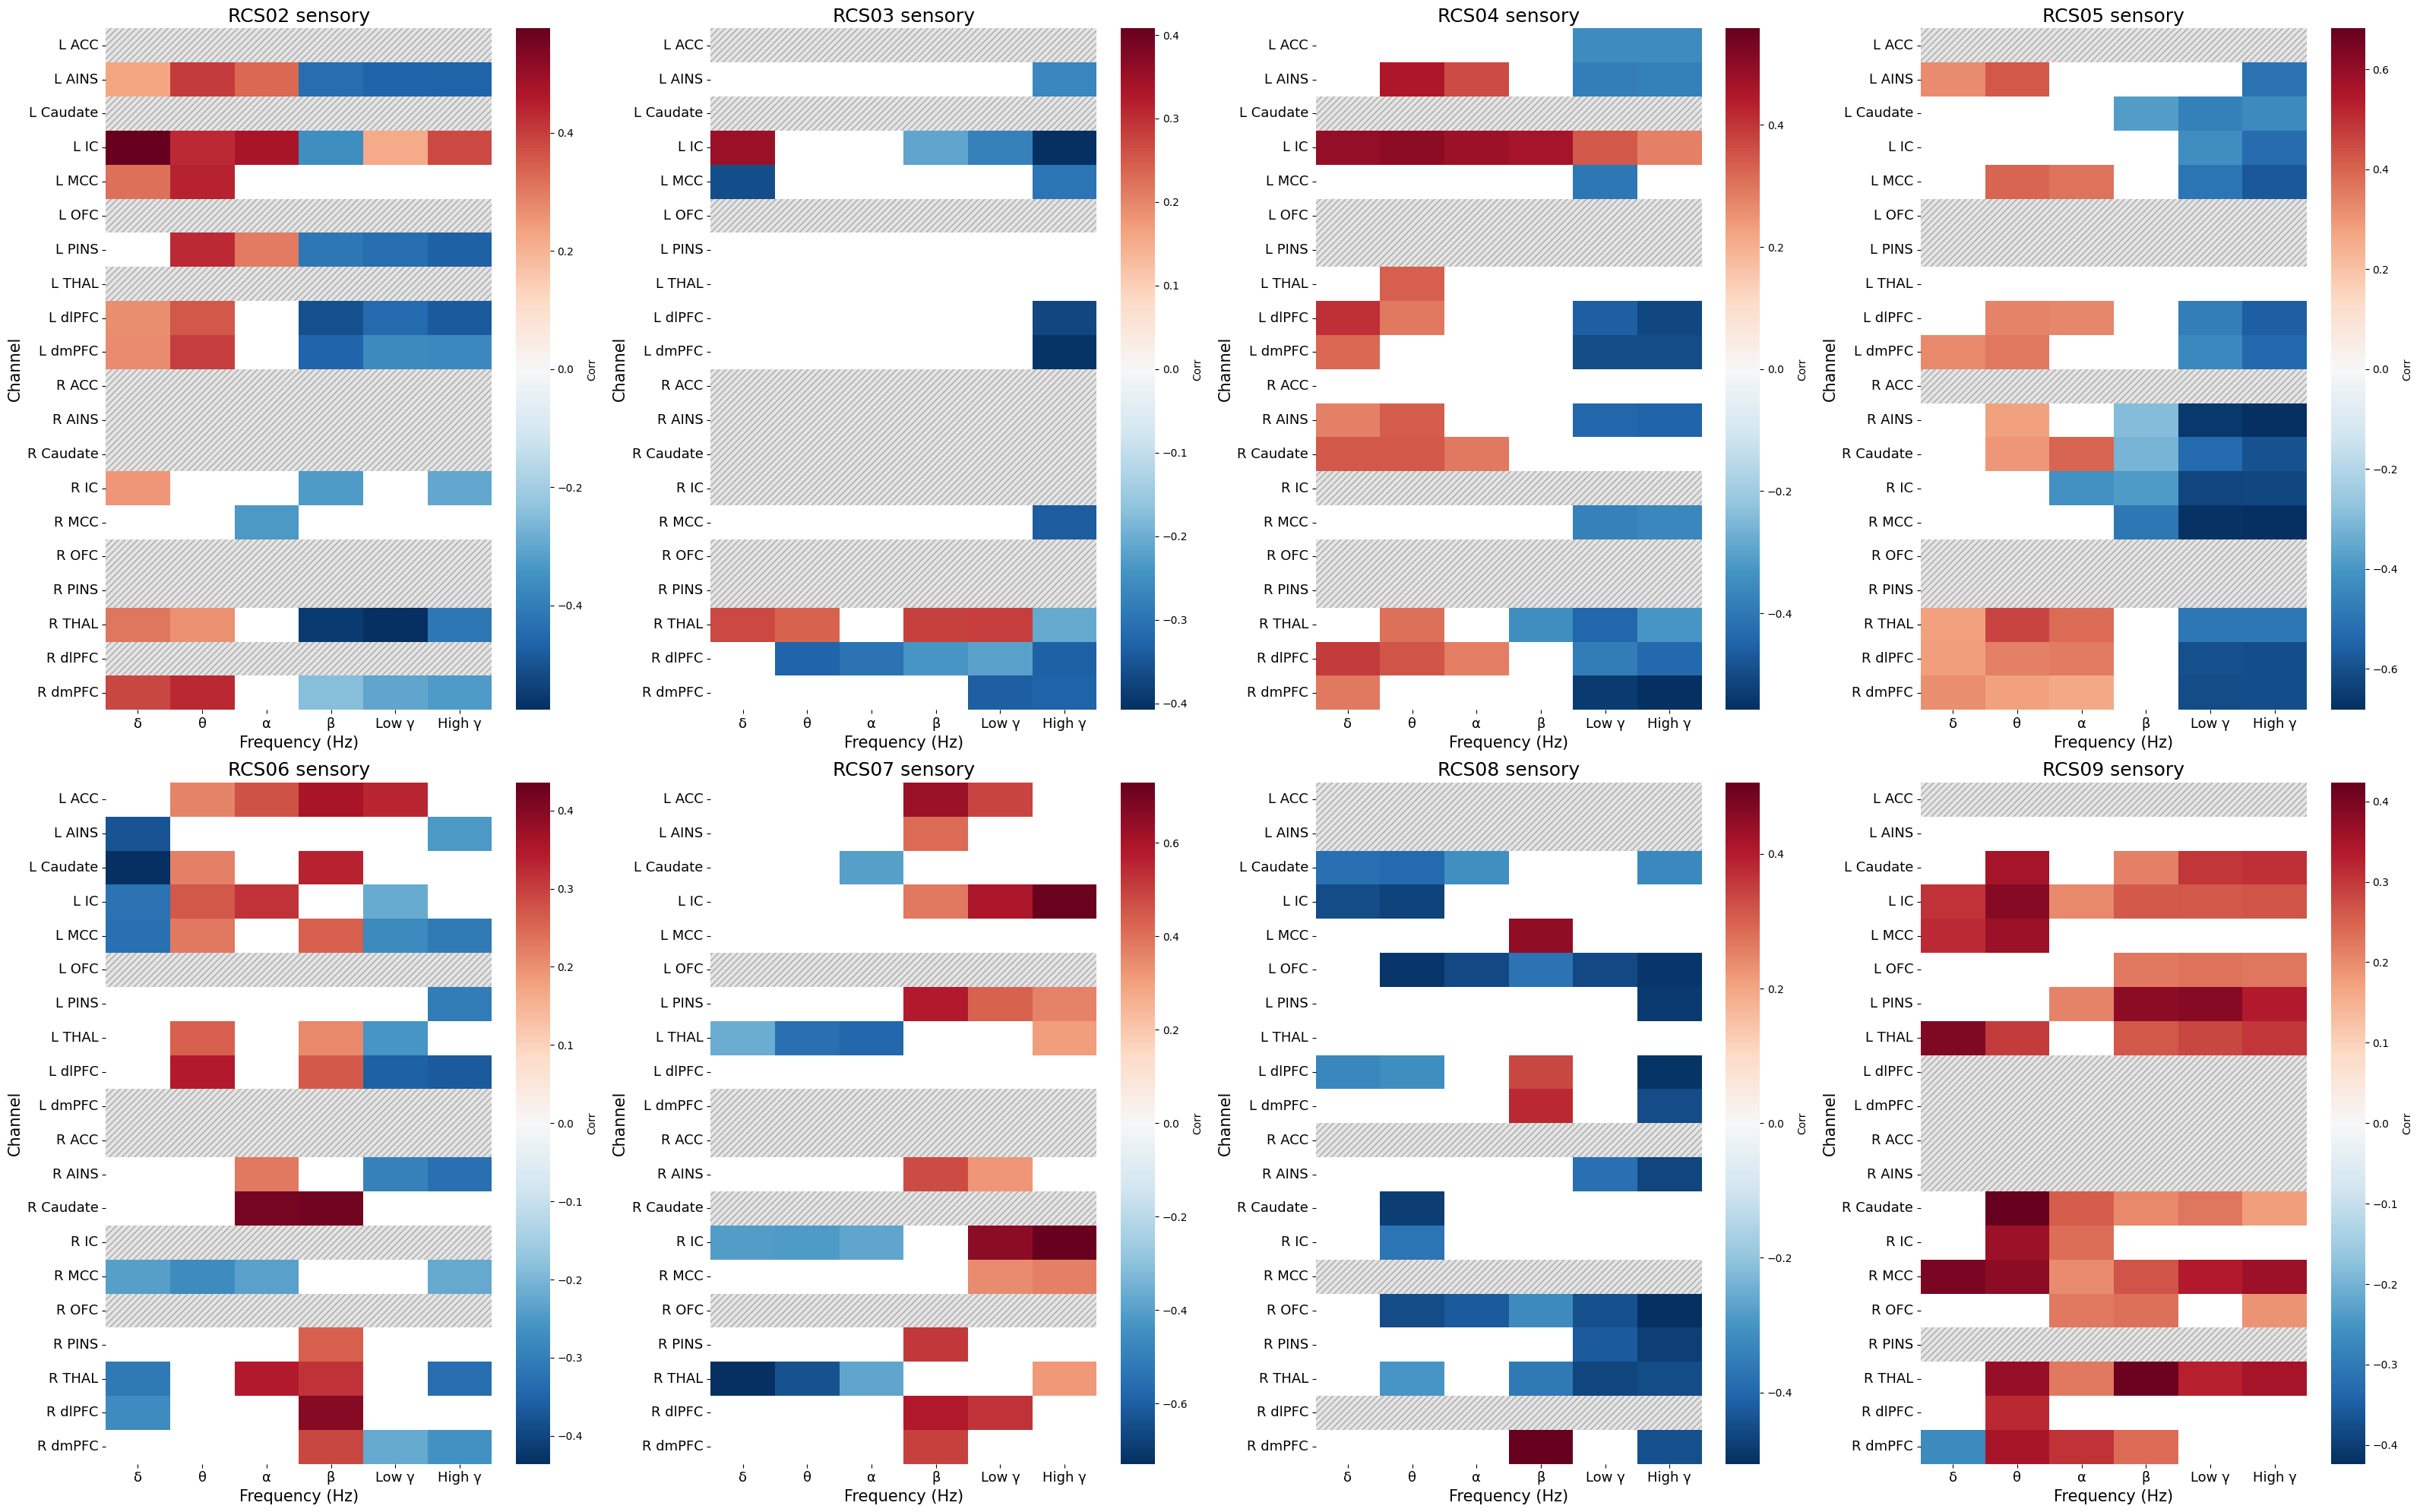

[0, 2, 5, 7, 10, 11, 12, 15, 16, 18]
[0, 2, 5, 10, 11, 12, 13, 15, 16]
[2, 5, 6, 13, 15, 16]
[0, 5, 6, 10, 15, 16]
[5, 9, 10, 13, 15]
[5, 9, 10, 12, 15]
[0, 1, 10, 14, 18]
[0, 8, 9, 10, 11, 16]


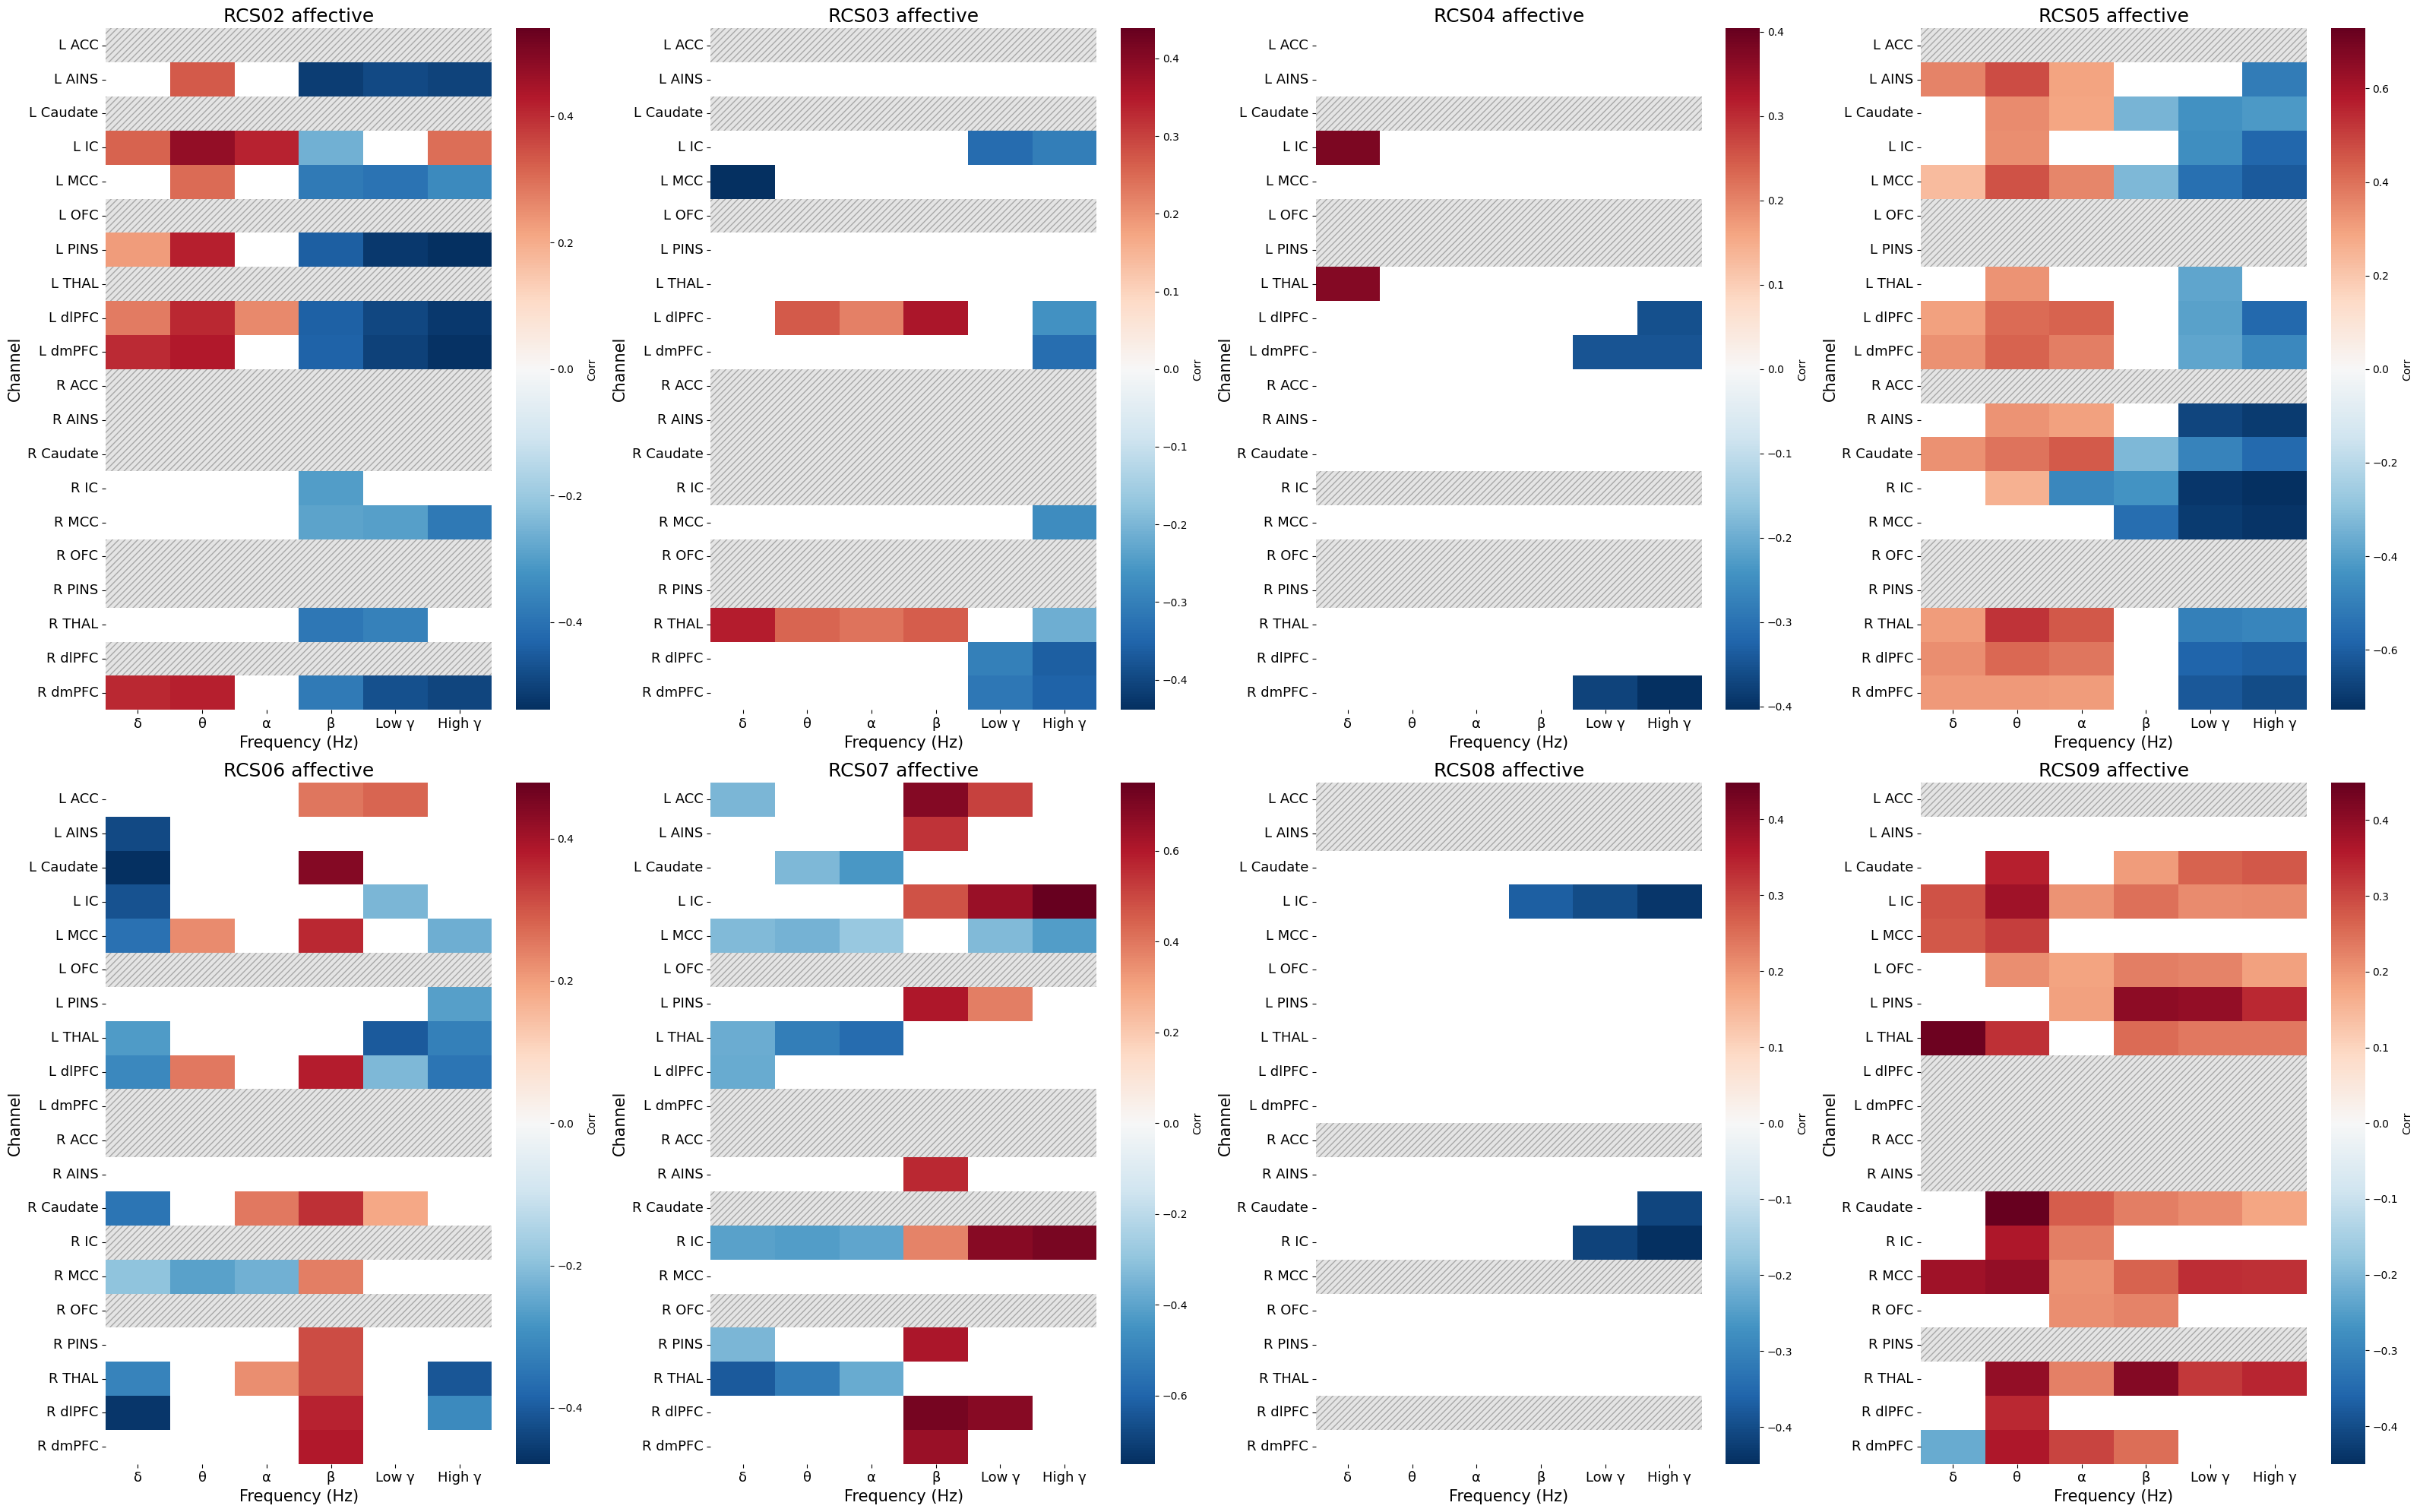

In [29]:
for behavior in behavior_types:

    plot_heatmap_subplots([corr_band_allpt[behavior][pt]['fdr'] for pt in ptIDs], [ch_allpt[pt] for pt in ptIDs],
                            ['δ', 'θ', 'α', 'β', 'Low γ', 'High γ'], ['Corr'] * len(ptIDs), [f'{pt} {behavior}' for pt in ptIDs],
                            f'20260702 Group Canonical Freq Corr FDR - {behavior}', nrows=2, ncols=4 )

In [ ]:

behavior_types = ['all', 'sensory', 'affective']
corr_band_channel_allpt = {'all': {}, 'sensory': {}, 'affective': {}}
for pt in ptIDs:
    for behavior in behavior_types:
        y = get_behavior_score(behav_score_allpt[pt], behavior)
        
        corr_bc, perm_p_bc = corr_permutation(
            all_data_clean_freq_z_allpt[pt],
            y,
            len(bands),
            len(all_channel_labels_allpt[pt])
        )
        
        corr_bc_uncorrected = np.where(perm_p_bc > 0.05, np.nan, corr_bc)
        corr_bc_fdr, reject_fdr = fdr_mask_roiwise(corr_bc, perm_p_bc)
        
        corr_band_channel_allpt[behavior][pt] = {
            'uncorrected': corr_bc_uncorrected,
            'fdr': corr_bc_fdr,
            'raw': corr_bc
        }
        
        basic_heatmap_channel(corr_bc_uncorrected, all_channel_labels_allpt[pt], canonical_freq,
                                'Corr', f'{pt} Per-channel canonical band vs {behavior} PC1 Uncorrected', True, savepath)
        basic_heatmap_channel(corr_bc_fdr, all_channel_labels_allpt[pt], canonical_freq,
                                'Corr', f'{pt} Per-channel canonical band vs {behavior} PC1 FDR', True, savepath)
        
        plot_freq_roi_dot_heatmap(corr_bc_uncorrected,all_channel_labels_allpt[pt],bands,new_labels_bi,
                f'{pt} Canonical Band x ROI (each dot is 1 channel) vs {behavior} Before FDR')
        plot_freq_roi_dot_heatmap(corr_bc_fdr,all_channel_labels_allpt[pt],bands,new_labels_bi,
                f'{pt} Canonical Band x ROI (each dot is 1 channel) vs {behavior} After FDR')

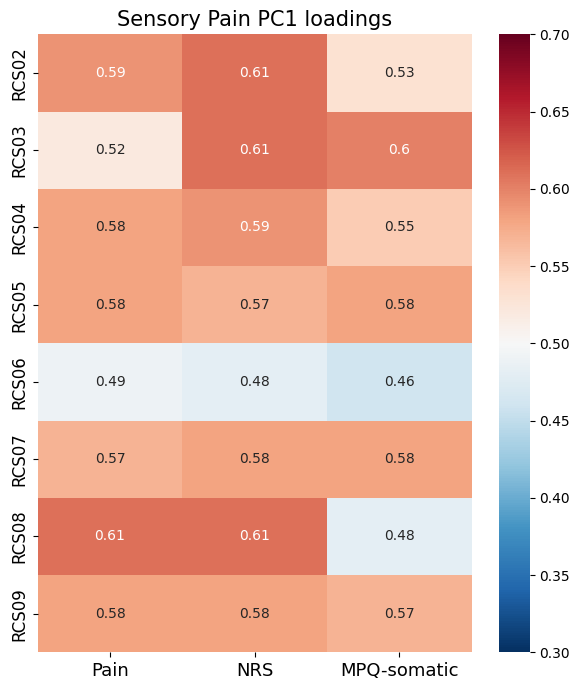

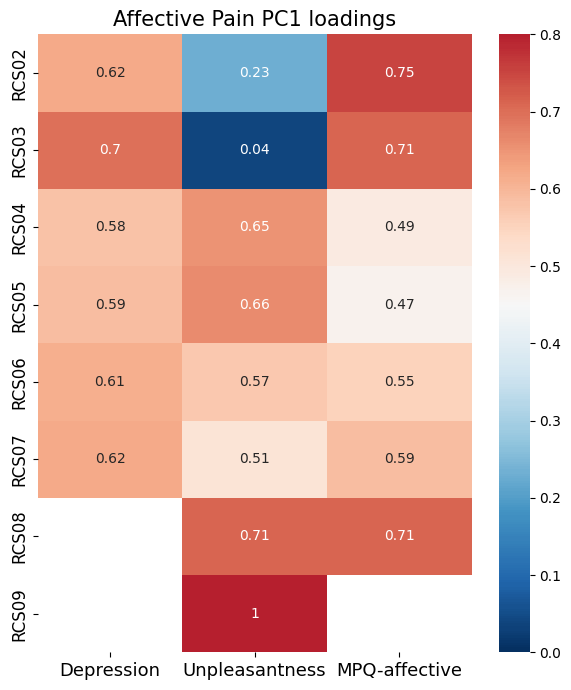

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Sensory Pain PC1 loadings ---
sensory_data = {
    'Pain':         [0.59, 0.52, 0.58, 0.58, 0.49, 0.57, 0.61, 0.58],
    'NRS':          [0.61, 0.61, 0.59, 0.57, 0.48, 0.58, 0.61, 0.58],
    'MPQ-somatic':  [0.53, 0.60, 0.55, 0.58, 0.46, 0.58, 0.48, 0.57],
}
ptIDs = ['RCS02','RCS03','RCS04','RCS05','RCS06','RCS07','RCS08','RCS09']

sensory_df = pd.DataFrame(sensory_data, index=ptIDs)

plt.figure(figsize=(6, 7))
sns.heatmap(sensory_df, annot=True, fmt='.2g', cmap='RdBu_r',
            vmin=0.3, vmax=0.7, center=0.5,
            cbar_kws={'label': ''})
plt.title('Sensory Pain PC1 loadings',fontsize=15)
plt.xlabel('')
plt.xticks(fontsize=13)
plt.ylabel('')
plt.yticks(fontsize=12,rotation=90)
plt.tight_layout()
plt.show()

# --- Affective Pain PC1 loadings ---
affective_data = {
    'Depression':          [0.62, 0.70, 0.58, 0.59, 0.61, 0.62, None, None],
    'Unpleasantness':  [0.23, 0.04, 0.65, 0.66, 0.57, 0.51, 0.71, 1.00],
    'MPQ-affective':   [0.75, 0.71, 0.49, 0.47, 0.55, 0.59, 0.71, None],
}

affective_df = pd.DataFrame(affective_data, index=ptIDs)

plt.figure(figsize=(6, 7))
sns.heatmap(affective_df, annot=True, fmt='.2g', cmap='RdBu_r',
            vmin=0, vmax=0.8, center=0.45,
            cbar_kws={'label': ''})
plt.title('Affective Pain PC1 loadings',fontsize=15)
plt.xlabel('')
plt.xticks(fontsize=13)
plt.ylabel('')
plt.yticks(fontsize=12,rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
def plot_freq_roi_dot_heatmap_ax(ax, corr_array, ch_labels, x_labels, roi_list, title, vmax, cmap='RdBu_r'):
    ch_roi = [re.sub(r'_\d+$', '', ch) for ch in ch_labels]
    n_freq = corr_array.shape[0]
    
    if vmax is None:
        vmax = np.nanmax(np.abs(corr_array))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    
    rois_present = set(ch_roi) 
    
    for fi in range(n_freq):
        for ri, roi in enumerate(roi_list):
            ch_idx = [i for i, r in enumerate(ch_roi) if r == roi]
            n = len(ch_idx)
            if n == 0:
                continue
            
            vals = corr_array[fi, ch_idx]
            vals = vals[~np.isnan(vals)]
            n_valid = len(vals)
            if n_valid == 0:
                continue
            
            if n_valid == 1:
                x_offsets = [0]
            else:
                x_offsets = np.linspace(-0.35, 0.35, n_valid)
            
            x_pos = fi + np.array(x_offsets)
            y_pos = np.full(n_valid, ri)
            ax.scatter(x_pos, y_pos, c=vals, cmap=cmap, norm=norm,
                        s=50, edgecolors='black', linewidths=0.3, zorder=3)
    
    # ---- Shade missing ROI ----
    for ri, roi in enumerate(roi_list):
        if roi not in rois_present:
            ax.add_patch(
                plt.Rectangle(
                    (-0.5, ri - 0.5), n_freq, 1,
                    facecolor='lightgray', alpha=0.5,
                    hatch='////', edgecolor='gray',
                    linewidth=0, zorder=1
                )
            )
    
    ax.set_xticks(range(n_freq))
    ax.set_xticklabels(x_labels, rotation=45, fontsize=12)
    ax.set_yticks(range(len(roi_list)))
    ax.set_yticklabels(roi_list, fontsize=12)
    
    ax.set_xticks(np.arange(-0.5, n_freq, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(roi_list), 1), minor=True)
    ax.grid(which='minor', color='lightgray', linewidth=0.4)
    ax.tick_params(which='minor', length=0)
    
    ax.set_xlim(-0.5, n_freq-0.5)
    ax.set_ylim(-0.5, len(roi_list)-0.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=16)

def plot_dot_grid(data_list, ch_labels_list, x_labels, roi_list, titles, savetitle, nrows=2, ncols=4, savepath="", save=True):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(1.5*4.2*ncols, 3*3.8*nrows),constrained_layout=True)
    axes = axes.flatten()
    
    all_vals = np.concatenate([arr[~np.isnan(arr)] for arr in data_list if np.any(~np.isnan(arr))])
    vmax = np.nanmax(np.abs(all_vals)) if len(all_vals) > 0 else 1
    
    for i, (arr, ch_labels, title) in enumerate(zip(data_list, ch_labels_list, titles)):
        plot_freq_roi_dot_heatmap_ax(axes[i], arr, ch_labels, x_labels, roi_list, title, vmax=vmax)
    
    for ax in axes[len(data_list):]:
        ax.axis('off')
    
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    sm = ScalarMappable(cmap='RdBu_r', norm=norm)
    fig.colorbar(sm, ax=axes[:len(data_list)], label='Correlation', shrink=0.6)
    fig.suptitle(savetitle, fontsize=14)

    if save:
        plt.savefig(f"{savepath}/{savetitle}.png", dpi=300, bbox_inches='tight')
    plt.show()

def basic_heatmap_channel_ax(ax, array, ch_labels, freqs, title, vmax):
    """array: n_freq x n_channel(该patient实际的channel数,不需要padding)"""
    ax.imshow(array.T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect='auto')
    
    ax.set_xticks(range(len(freqs)))
    ax.set_xticklabels(freqs, rotation=45, fontsize=6)
    
    ax.set_yticks(range(len(ch_labels)))
    ax.set_yticklabels(ch_labels, fontsize=5)
    
    ax.set_title(title, fontsize=8)


def plot_heatmap_channel_grid(data_list, ch_labels_list, freqs, label, titles, savetitle, 
                                 nrows=2, ncols=4, savepath="", save=True):
    max_n_ch = max(len(ch) for ch in ch_labels_list)
    row_height = 0.18
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                               figsize=(3.5*ncols, max(row_height*max_n_ch, 4)*nrows),constrained_layout=True)
    axes = axes.flatten()
    
    all_vals = np.concatenate([arr[~np.isnan(arr)] for arr in data_list if np.any(~np.isnan(arr))])
    vmax = np.nanmax(np.abs(all_vals)) if len(all_vals) > 0 else 1
    
    for i, (arr, ch_labels, title) in enumerate(zip(data_list, ch_labels_list, titles)):
        basic_heatmap_channel_ax(axes[i], arr, ch_labels, freqs, title, vmax=vmax)
    
    for ax in axes[len(data_list):]:
        ax.axis('off')
    

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    sm = ScalarMappable(cmap='RdBu_r', norm=norm)
    fig.colorbar(sm, ax=axes[:len(data_list)], label=label, shrink=0.6)
    
    fig.suptitle(savetitle, fontsize=14)
    if save:
        plt.savefig(f"{savepath}/{savetitle}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
import pickle

save_dir = f"/home/jiahuang/test-code-hazel"

with open(f"{save_dir}/corr_band_channel_allpt.pkl", "wb") as f:
    pickle.dump(corr_band_channel_allpt, f)

with open(f"{save_dir}/all_channel_labels_allpt.pkl", "wb") as f:
    pickle.dump(all_channel_labels_allpt, f)

In [ ]:
for behavior in ['affective', 'sensory']:
    for correction in ['uncorrected', 'fdr']:
        
        plot_dot_grid(
            [corr_band_channel_allpt[behavior][pt][correction] for pt in ptIDs],
            [all_channel_labels_allpt[pt] for pt in ptIDs],
            bands, new_labels_bi,
            [f'{pt}' for pt in ptIDs],
            f'202607 Group Dot Canonical Band - {behavior} - {correction}',
            nrows=2, ncols=4, savepath=savepath
        )
        
        # plot_heatmap_channel_grid(
        #     [corr_band_channel_allpt[behavior][pt][correction] for pt in ptIDs],
        #     [all_channel_labels_allpt[pt] for pt in ptIDs],
        #     bands,
        #     [f'{pt}' for pt in ptIDs],
        #     f'202607 Group Heatmap PerChannel Canonical Band - {behavior} - {correction}',
        #     nrows=2, ncols=4, savepath=savepath
        # )

In [30]:
import pickle

save_dir = f"/home/jiahuang/test-code-hazel"
corr_band_channel_allpt = pd.read_pickle(f"{save_dir}/corr_band_channel_allpt.pkl")
all_channel_labels_allpt = pd.read_pickle(f"{save_dir}/all_channel_labels_allpt.pkl")

In [ ]:
from scipy import stats
import statsmodels.api as sm
from patsy import dmatrices

for ptID in ptIDs:
    ch_labels = all_channel_labels_allpt[ptID]
    n_ch = len(ch_labels)
    n_bands = len(bands)
    n_feats = n_ch * n_bands
    
    X1 = all_data_clean_freq_z_allpt[ptID]
    
    # Yd = get_behavior_score(behav_score_allpt[ptID], 'affective')
    # Yp = get_behavior_score(behav_score_allpt[ptID], 'sensory')
    
    Yd = behavior_raw_allpt[ptID]['affective']
    Yp = behavior_raw_allpt[ptID]['somatic']
    behavior_pairs = [
        # ('Sensory', Yp, 'Affective', Yd),
        # ('Affective', Yd, 'Sensory', Yp),
        ('MPQ Somatic', Yp, 'MPQ Affective', Yd),
        ('MPQ Affective', Yd, 'MPQ Somatic', Yp),
    ]
    
    raw_arrays = []
    masked_arrays = []
    raw_titles = []
    masked_titles = []
    pcorr_ch_labels = []
    
    for target_name, Y_target, control_name, Y_control in behavior_pairs:
        slope_YY, intercept_YY, _, _, _ = stats.linregress(Y_control, Y_target)
        Y_pred = slope_YY * Y_control + intercept_YY
        Y_resid = Y_target - Y_pred
        
        X_resid = np.zeros_like(X1)
        for j in range(n_feats):
            slope_XZ, intercept_XZ, _, _, _ = stats.linregress(Y_control, X1[:, j])
            X_pred = slope_XZ * Y_control + intercept_XZ
            X_resid[:, j] = X1[:, j] - X_pred
        
        partial_corr = np.zeros(n_feats)
        partial_corr_p = np.zeros(n_feats)
        for j in range(n_feats):
            partial_corr[j], partial_corr_p[j] = stats.pearsonr(X_resid[:, j], Y_resid)
        
        partial_corr_mask = np.where(partial_corr_p > 0.05, np.nan, partial_corr)
        
        pcorr_reshaped = partial_corr.reshape(n_bands, n_ch)
        pcorr_reshaped_mask = partial_corr_mask.reshape(n_bands, n_ch)
        
        raw_arrays.append(pcorr_reshaped)
        raw_titles.append(f'{target_name} | {control_name} - Raw')
        
        masked_arrays.append(pcorr_reshaped_mask)
        masked_titles.append(f'{target_name} | {control_name} - p<0.05')
        
        pcorr_ch_labels.append(ch_labels)
    
    
    # plot_heatmap_channel_grid(
    #     raw_arrays,
    #     pcorr_ch_labels,
    #     bands,
    #     'Partial Corr',
    #     raw_titles,
    #     f'Partial Correlation Raw - {ptID}',
    #     nrows=1, ncols=2,save=False
    # )
    
    # plot_heatmap_channel_grid(
    #     masked_arrays,
    #     pcorr_ch_labels,
    #     bands,
    #     'Partial Corr',
    #     masked_titles,
    #     f'Partial Correlation p<0.05 - {ptID}',
    #     nrows=1, ncols=2,save=False
    # )
    
    # ---OLS t-stats ---
    df = pd.DataFrame({'Affective': Yd, 'Sensory': Yp})
    for j in range(n_feats):
        df[f'PSD{j}'] = X1[:, j]
    
    t_vals_aff, p_vals_aff = [], []
    t_vals_sens, p_vals_sens = [], []
    
    for j in range(n_feats):
        formula = f'PSD{j} ~ Affective + Sensory'
        y, Xd = dmatrices(formula, data=df, return_type='dataframe')
        res = sm.OLS(y, Xd).fit()
        
        t_vals_aff.append(res.tvalues['Affective'])
        p_vals_aff.append(res.pvalues['Affective'])
        
        t_vals_sens.append(res.tvalues['Sensory'])
        p_vals_sens.append(res.pvalues['Sensory'])
    
    tval_reshape_aff = np.reshape(t_vals_aff, [n_bands, n_ch])
    pval_reshape_aff = np.reshape(p_vals_aff, [n_bands, n_ch])
    tval_reshape_sens = np.reshape(t_vals_sens, [n_bands, n_ch])
    pval_reshape_sens = np.reshape(p_vals_sens, [n_bands, n_ch])
    
    masked_t_vals_aff = np.where(pval_reshape_aff > 0.05, np.nan, tval_reshape_aff)
    masked_t_vals_sens = np.where(pval_reshape_sens > 0.05, np.nan, tval_reshape_sens)
    
    # plot_heatmap_channel_grid(
    #     [masked_t_vals_sens, masked_t_vals_aff],
    #     [ch_labels, ch_labels],
    #     bands,
    #     'Tstats',
    #     [f'OLS PSD vs Sensory {ptID}', f'OLS PSD vs Affective {ptID}'],
    #     f'All channel canonical frequency OLS T-stats - {ptID}',
    #     nrows=1, ncols=2,save=False
    # )

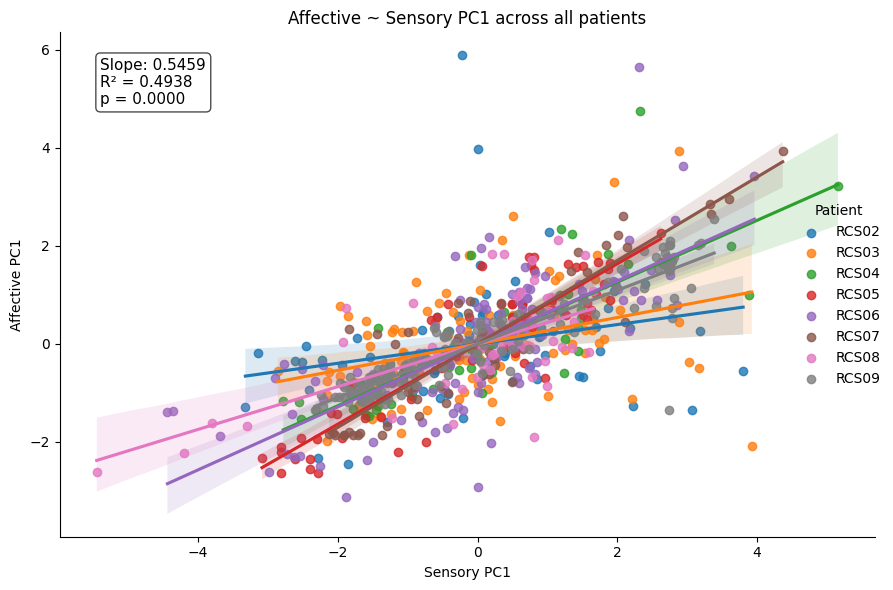

In [46]:
from scipy import stats

all_aff = np.array([])
all_sens = np.array([])
all_pts = np.array([])

for ptID in ptIDs:
    aff = get_behavior_score(behav_score_allpt[ptID], 'affective')
    sens = get_behavior_score(behav_score_allpt[ptID], 'sensory')
    all_aff = np.concatenate((all_aff, aff))
    all_sens = np.concatenate((all_sens, sens))
    all_pts = np.concatenate((all_pts, np.repeat(ptID, len(aff))))

slope, intercept, r_value, p_value, std_err = stats.linregress(all_sens, all_aff)
r2 = r_value**2

df_plot = pd.DataFrame({'Affective PC1': all_aff, 'Sensory PC1': all_sens, 'Patient': all_pts})

g = sns.lmplot(df_plot, x='Sensory PC1', y='Affective PC1',
               hue='Patient', legend=True, fit_reg=True,
               height=6, aspect=8/6)

textstr = f'Slope: {slope:.4f}\nR² = {r2:.4f}\np = {p_value:.4f}'
g.ax.text(0.05, 0.95, textstr, transform=g.ax.transAxes,
          fontsize=11, verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

g.ax.set_title("Affective ~ Sensory PC1 across all patients")
plt.tight_layout()
plt.show()

In [13]:
import pickle

pcorr_affective_masked_allpt = {}
pcorr_ch_labels_allpt = {}

for ptID in ptIDs:
    ch_labels = all_channel_labels_allpt[ptID]
    n_ch = len(ch_labels)
    n_bands = len(bands)
    n_feats = n_ch * n_bands
    
    X1 = all_data_clean_freq_z_allpt[ptID]
    
    # Yd = get_behavior_score(behav_score_allpt[ptID], 'affective')  # affective(target)
    # Yp = get_behavior_score(behav_score_allpt[ptID], 'sensory')    # sensory(control)
    Yd = behavior_raw_allpt[ptID]['affective']
    Yp = behavior_raw_allpt[ptID]['somatic']
    behavior_pairs = [
        # ('Sensory', Yp, 'Affective', Yd),
        # ('Affective', Yd, 'Sensory', Yp),
        ('MPQ Somatic', Yp, 'MPQ Affective', Yd),
        ('MPQ Affective', Yd, 'MPQ Somatic', Yp),
    ]

    # affective controlling for sensory
    slope_YY, intercept_YY, _, _, _ = stats.linregress(Yp, Yd)
    Yd_pred = slope_YY * Yp + intercept_YY
    Y_resid = Yd - Yd_pred
    
    X_resid = np.zeros_like(X1)
    for j in range(n_feats):
        slope_XZ, intercept_XZ, _, _, _ = stats.linregress(Yp, X1[:, j])
        X_pred = slope_XZ * Yp + intercept_XZ
        X_resid[:, j] = X1[:, j] - X_pred
    
    partial_corr = np.zeros(n_feats)
    partial_corr_p = np.zeros(n_feats)
    for j in range(n_feats):
        partial_corr[j], partial_corr_p[j] = stats.pearsonr(X_resid[:, j], Y_resid)
    
    partial_corr_mask = np.where(partial_corr_p > 0.05, np.nan, partial_corr)
    pcorr_reshaped_mask = partial_corr_mask.reshape(n_bands, n_ch)
    
    pcorr_affective_masked_allpt[ptID] = pcorr_reshaped_mask
    pcorr_ch_labels_allpt[ptID] = ch_labels

save_dir = f"/home/jiahuang/test-code-hazel"
os.makedirs(save_dir, exist_ok=True)

with open(f"{save_dir}/pcorr_MPQ_affective_masked_allpt.pkl", "wb") as f:
    pickle.dump(pcorr_affective_masked_allpt, f)

# with open(f"{save_dir}/pcorr_ch_labels_allpt.pkl", "wb") as f:
#     pickle.dump(pcorr_ch_labels_allpt, f)

In [ ]:
plot_heatmap_channel_grid(
    [pcorr_affective_masked_allpt[pt] for pt in ptIDs],
    [pcorr_ch_labels_allpt[pt] for pt in ptIDs],
    bands,'Partial Corr',
    [f'{pt}' for pt in ptIDs],
    'Partial Correlation (MPQ Affective | MPQ Somatic) p<0.05 - All Patients',
    nrows=2, ncols=4, save=False
)

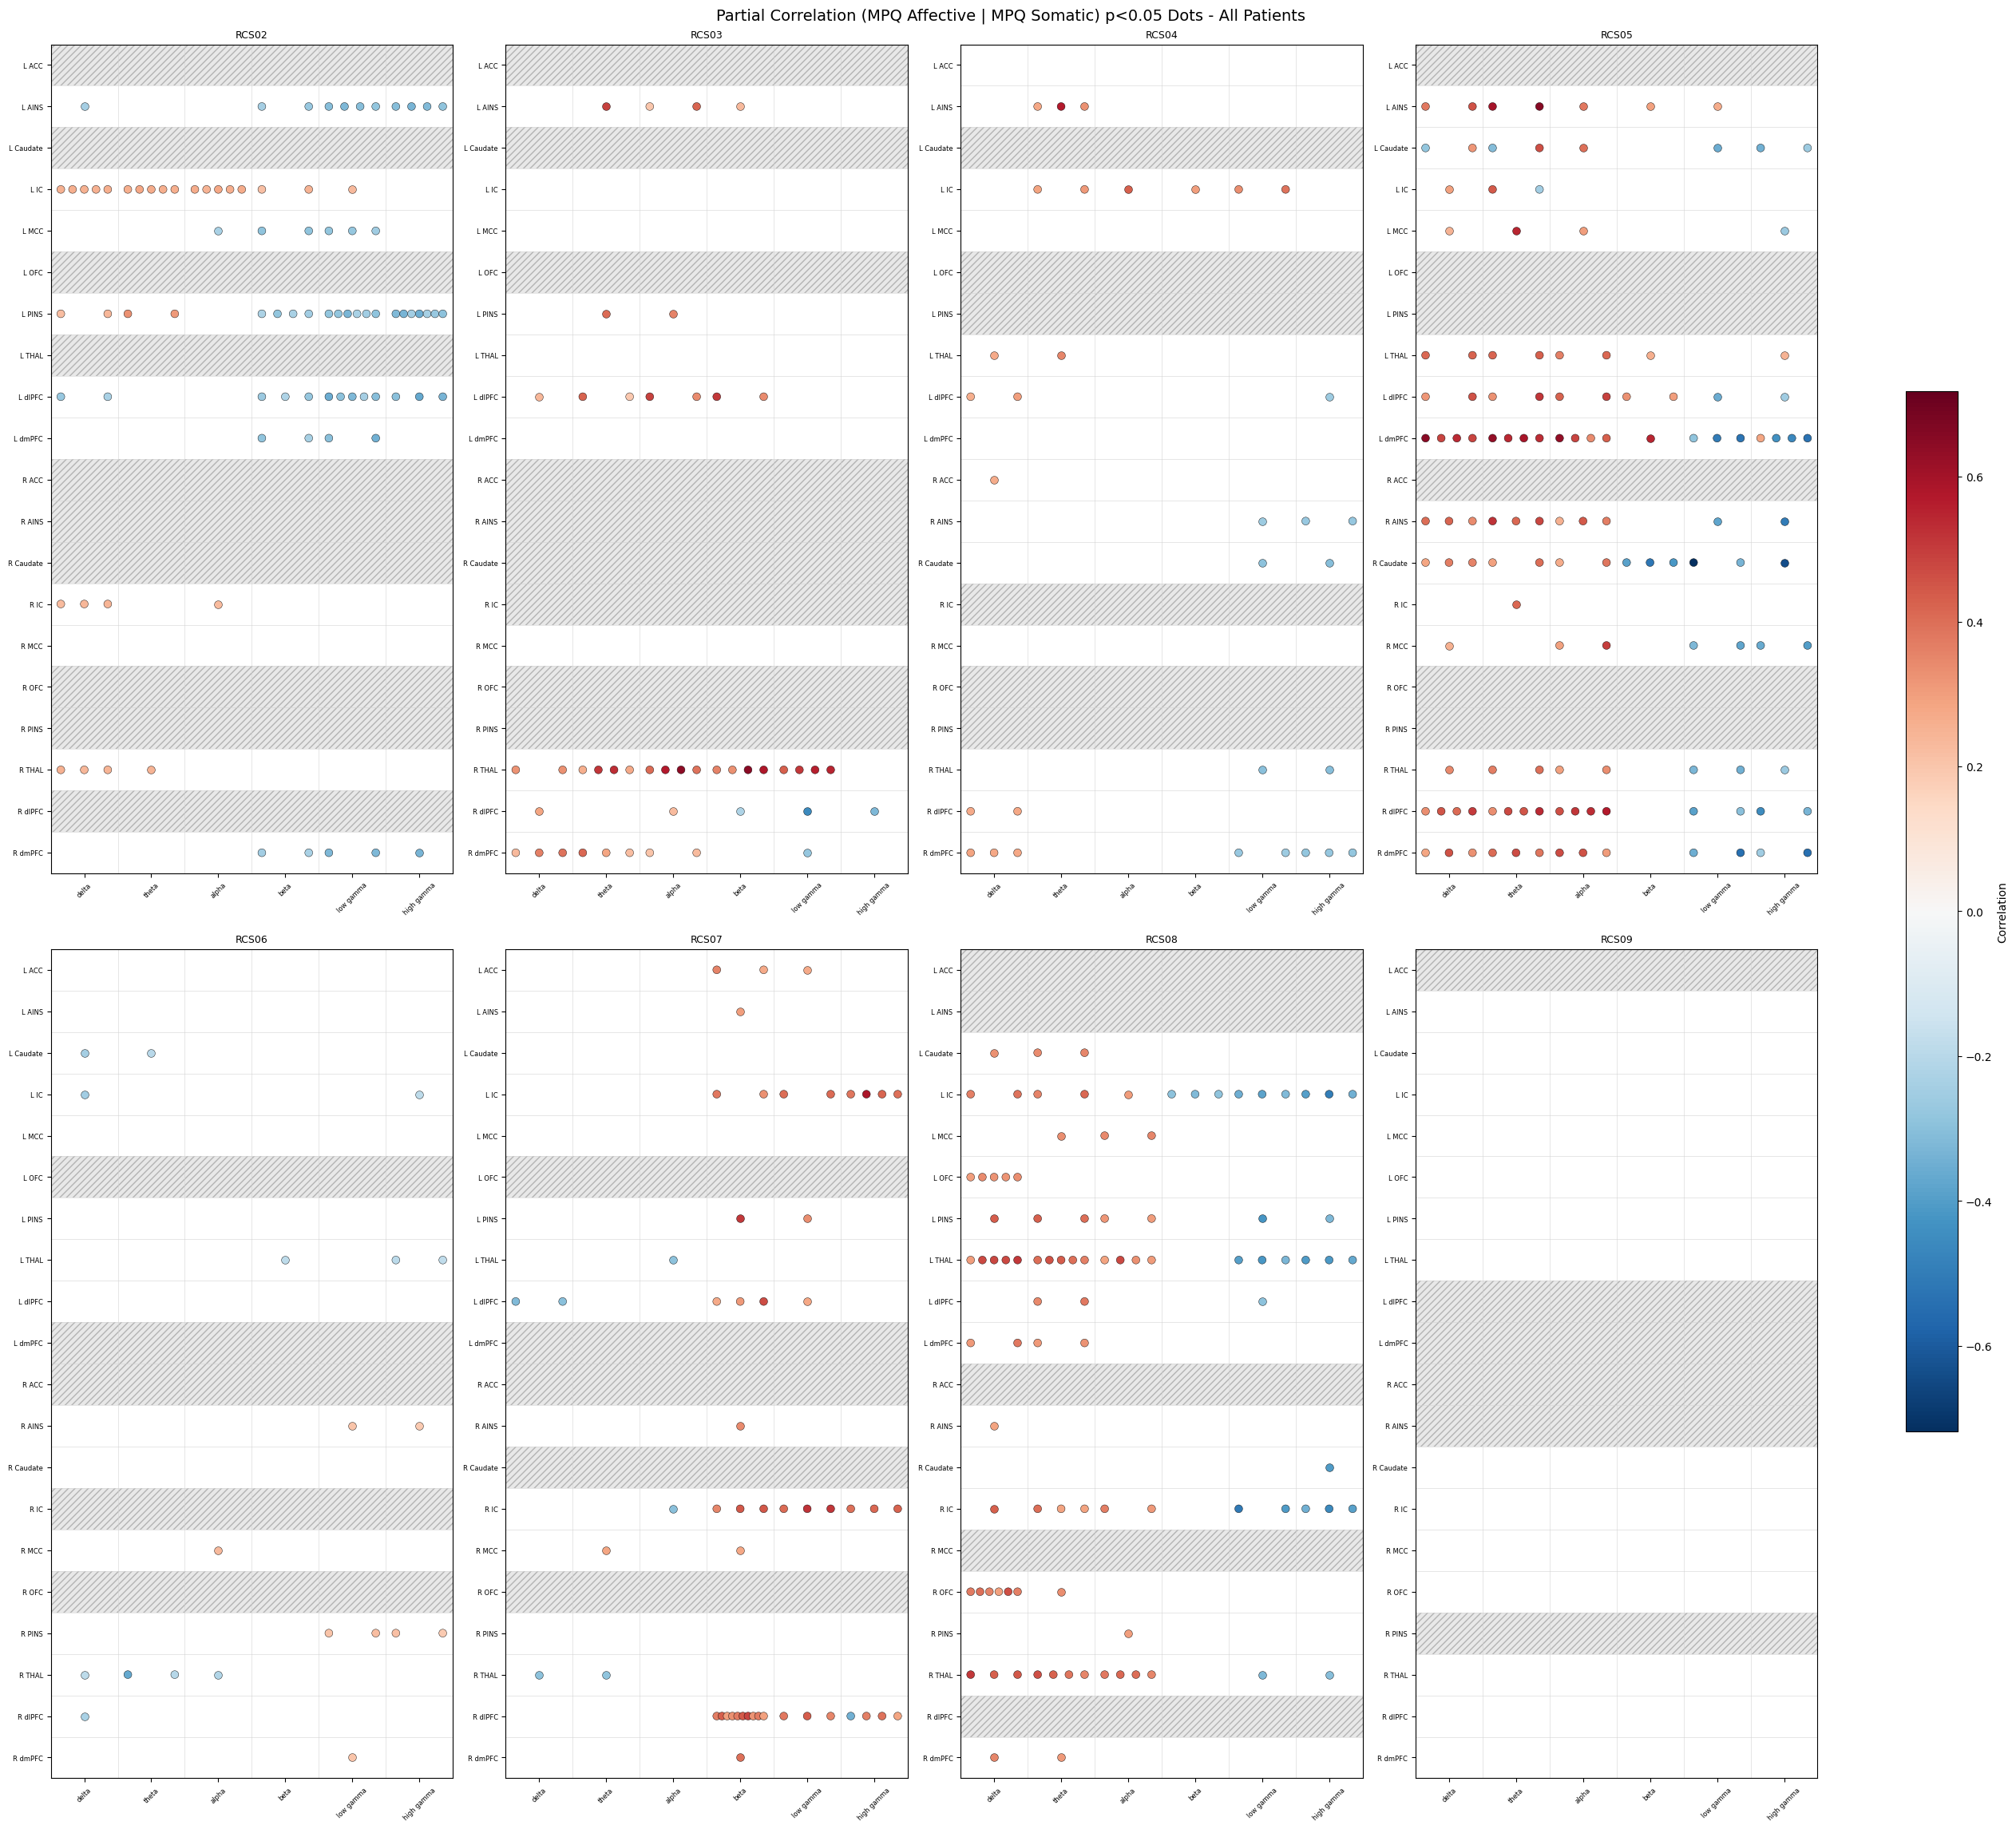

In [15]:
plot_dot_grid(
    [pcorr_affective_masked_allpt[pt] for pt in ptIDs],
    [pcorr_ch_labels_allpt[pt] for pt in ptIDs],
    bands, new_labels_bi,
    [f'{pt}' for pt in ptIDs],
    'Partial Correlation (MPQ Affective | MPQ Somatic) p<0.05 Dots - All Patients',
    nrows=2, ncols=4, save=False
)

In [ ]:
def plot_cos_similarity_heatmap(df, ptIDs_order, rois_order, title, cmap='RdBu_r', alpha=0.05):
    fig, ax = plt.subplots(figsize=(1.3*len(ptIDs_order)+2, 0.7*len(rois_order)+2))
    n_matrix = np.zeros((len(rois_order), len(ptIDs_order)), dtype=int)
    cos_matrix = np.full((len(rois_order), len(ptIDs_order)), np.nan)
    
    for i, roi in enumerate(rois_order):
        for j, ptID in enumerate(ptIDs_order):
            sub = df[(df['roi']==roi) & (df['ptID']==ptID)]
            sub_sig = sub[(sub['p_sensory'] < alpha) | (sub['p_affective'] < alpha)]
            
            n = sub_sig.shape[0]
            if n < 3:
                continue
            
            b_sens_sig = sub_sig['beta_sensory'].values
            b_aff_sig = sub_sig['beta_affective'].values
            norm_sens = np.linalg.norm(b_sens_sig)
            norm_aff = np.linalg.norm(b_aff_sig)
            
            cos_matrix[i, j] = np.dot(b_sens_sig, b_aff_sig) / (norm_sens * norm_aff)
            
    im = ax.imshow(cos_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
    
    for j, ptID in enumerate(ptIDs_order):

        rois_present = set(df.loc[df['ptID'] == ptID, 'roi'])

        for i, roi in enumerate(rois_order):
            if roi not in rois_present:
                ax.add_patch(
                    plt.Rectangle(
                        (j - 0.5, i - 0.5),
                        1,
                        1,
                        facecolor='lightgray',
                        alpha=0.5,
                        hatch='////',
                        edgecolor='gray',
                        linewidth=0,
                        zorder=1
                    )
                )
                
    ax.set_xticks(range(len(ptIDs_order)))
    ax.set_xticklabels(ptIDs_order, rotation=45, ha='right')
    ax.set_yticks(range(len(rois_order)))
    ax.set_yticklabels(rois_order)
    
    plt.colorbar(im, ax=ax, label='Cosine similarity (sensory vs affective β)')
    ax.set_title(title + f'\n(only channels with p < {alpha} and ROI more than 3 channels)')
    plt.tight_layout()
    plt.show()

plot_cos_similarity_heatmap(summary_df, ptIDs_order, rois_order, 
                              'Cosine Similarity: Sensory vs Affective')